# fe_01. Encoding ciclic pentru variabilele temporale

**Pregatire SCSS 2026 - Diana Nenu**

Acest notebook explica simplu si concret de ce avem nevoie de encoding ciclic pentru variabile temporale (ora, zi a saptamanii, luna) cand lucram cu date energetice si cum se implementeaza in Python.

**Plan:**
1. Aratam problema reprezentarii liniare (ora 23 si 0 par 'departe')
2. Construim solutia matematica (sin si cos pe cerc)
3. Calculam concret distantele intre ore in cele 2 reprezentari
4. Aplicam pe date energetice reale (consum SUA) si comparam impactul pe model

## 1.1 Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
np.random.seed(42)

## 1.2 Problema: ora ca numar liniar

Cand avem date energetice cu coloana 'ora' valoarea variaza de la 0 la 23. Pare normal sa o folosim direct ca feature numeric. **Dar e o capcana.**

In datele reale, **consumul de electricitate la ora 23:00 si la ora 0:00 este similar** - amandoua sunt noapte tarziu, oamenii dorm, fabricile inchise, iluminat public minim.

Daca codificam ora ca numere 0, 1, 2, ..., 23, modelul ML vede:
- ora 22 si ora 23 -> distanta 1 (vecini)
- ora 23 si ora 0 -> distanta 23 (departe!)

Distanta 23 este o **inventie a reprezentarii** - in realitate fizica, cele doua ore sunt vecine.

In [2]:
# Simulez profilul orar tipic de consum energetic (date sintetice realiste)
ore = np.arange(0, 24)
# Maxim la 19-20 (cina + iluminat), minim la 4-5 dimineata
consum = 25 + 7 * np.cos(2 * np.pi * (ore - 19) / 24) + np.random.normal(0, 0.3, 24)

df_ore = pd.DataFrame({'ora': ore, 'consum_GW': consum.round(2)})
print('Consum tipic pe ore:')
print(df_ore.head(5))
print('...')
print(df_ore.tail(5))
print(f'\nDiferenta consum intre ora 23 si ora 0: {abs(consum[23] - consum[0]):.2f} GW')
print('(Mica - aproape acelasi consum, ambele noaptea tarziu)')

Consum tipic pe ore:
   ora  consum_GW
0    0      26.96
1    1      24.96
2    2      23.38
3    3      21.96
4    4      19.98
...
    ora  consum_GW
19   19      31.58
20   20      32.20
21   21      30.99
22   22      29.97
23   23      28.07

Diferenta consum intre ora 23 si ora 0: 1.11 GW
(Mica - aproape acelasi consum, ambele noaptea tarziu)


## 1.3 Solutia: encoding ciclic cu sin si cos

Solutia matematica este sa **plasam orele pe un cerc trigonometric** in loc de o linie dreapta. Cercul ne da continuitatea naturala - dupa pozitia ultima (ora 23) urmeaza prima (ora 0).

Formula:
$$\text{hour\_sin} = \sin\left(\frac{2\pi \cdot h}{24}\right)$$
$$\text{hour\_cos} = \cos\left(\frac{2\pi \cdot h}{24}\right)$$

Acum **inlocuim** coloana 'ora' cu **doua coloane** (sin si cos). Modelul vede o pozitie unica pe cerc pentru fiecare ora.

**De ce avem nevoie de DOUA coloane?** Pentru ca un punct pe cerc se identifica prin doua coordonate (x, y) - o singura valoare (sin sau cos) e ambigua (sinusul orei 5 si orei 7 sunt egale).

In [3]:
# Calculez encoding ciclic pentru fiecare ora
df_ore['hour_sin'] = np.sin(2 * np.pi * df_ore['ora'] / 24)
df_ore['hour_cos'] = np.cos(2 * np.pi * df_ore['ora'] / 24)
print(df_ore[['ora', 'hour_sin', 'hour_cos']].round(3))

    ora  hour_sin  hour_cos
0     0     0.000     1.000
1     1     0.259     0.966
2     2     0.500     0.866
3     3     0.707     0.707
4     4     0.866     0.500
5     5     0.966     0.259
6     6     1.000     0.000
7     7     0.966    -0.259
8     8     0.866    -0.500
9     9     0.707    -0.707
10   10     0.500    -0.866
11   11     0.259    -0.966
12   12     0.000    -1.000
13   13    -0.259    -0.966
14   14    -0.500    -0.866
15   15    -0.707    -0.707
16   16    -0.866    -0.500
17   17    -0.966    -0.259
18   18    -1.000    -0.000
19   19    -0.966     0.259
20   20    -0.866     0.500
21   21    -0.707     0.707
22   22    -0.500     0.866
23   23    -0.259     0.966


## 1.4 Comparatie numerica: cat de 'vecine' sunt ora 23 si ora 0?

Calculez distanta euclidiana intre ora 23 si ora 0 in cele doua reprezentari:
- **liniar**: |23 - 0| = 23 (mare!)
- **ciclic**: distanta euclidiana intre punctele (sin, cos) corespondente

In [4]:
# Coordonatele pe cerc pentru cele doua ore
p23 = (df_ore.loc[23, 'hour_sin'], df_ore.loc[23, 'hour_cos'])
p0  = (df_ore.loc[0,  'hour_sin'], df_ore.loc[0,  'hour_cos'])

# Distanta euclidiana = sqrt((sin23-sin0)^2 + (cos23-cos0)^2)
dist_ciclic = np.sqrt((p23[0] - p0[0])**2 + (p23[1] - p0[1])**2)
print(f'Ora 23 pe cerc: (sin={p23[0]:.3f}, cos={p23[1]:.3f})')
print(f'Ora  0 pe cerc: (sin={p0[0]:.3f}, cos={p0[1]:.3f})')
print(f'\nDistanta euclidiana pe cerc: {dist_ciclic:.4f}')
print(f'Distanta liniara (gresita):  23.0')
print(f'\n=> Pe cerc, ora 23 si ora 0 sunt practic vecine (~ 0.26 unitati), exact cum sunt si fizic.')

Ora 23 pe cerc: (sin=-0.259, cos=0.966)
Ora  0 pe cerc: (sin=0.000, cos=1.000)

Distanta euclidiana pe cerc: 0.2611
Distanta liniara (gresita):  23.0

=> Pe cerc, ora 23 si ora 0 sunt practic vecine (~ 0.26 unitati), exact cum sunt si fizic.


## 1.5 Vizualizare: linie vs cerc

Pun cele 24 de ore pe linie (stanga) si pe cerc (dreapta), colorate dupa consum.

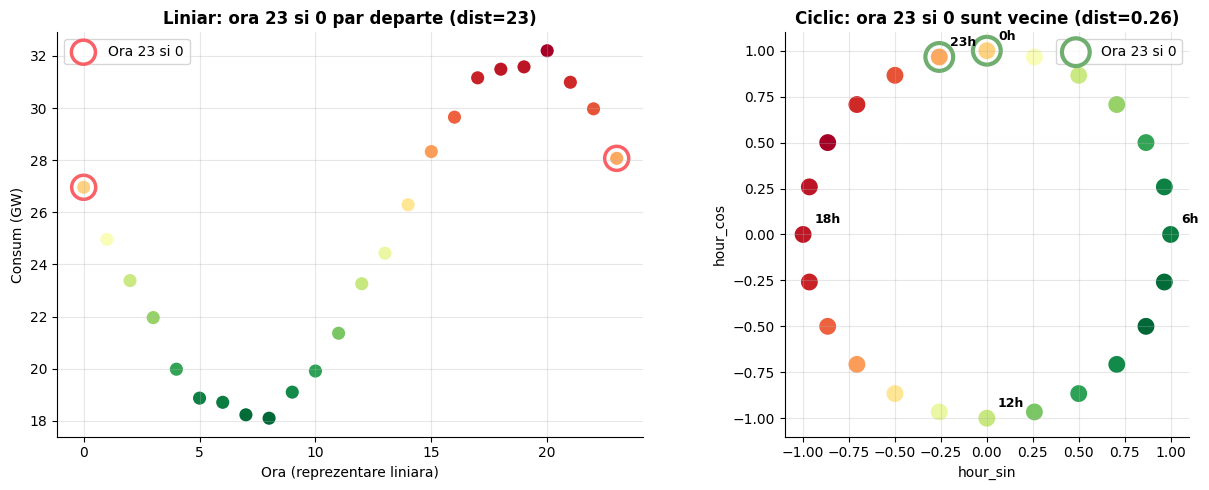

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Stanga - liniar
ax = axes[0]
ax.scatter(df_ore['ora'], df_ore['consum_GW'], c=df_ore['consum_GW'],
           cmap='RdYlGn_r', s=120, edgecolor='white', linewidth=1.5)
# Highlight 23 si 0
ax.scatter([23, 0], df_ore.loc[[23, 0], 'consum_GW'], s=300,
           facecolors='none', edgecolors='#F96167', lw=2.5, label='Ora 23 si 0')
ax.set_xlabel('Ora (reprezentare liniara)')
ax.set_ylabel('Consum (GW)')
ax.set_title('Liniar: ora 23 si 0 par departe (dist=23)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Dreapta - ciclic (sin, cos)
ax = axes[1]
ax.scatter(df_ore['hour_sin'], df_ore['hour_cos'], c=df_ore['consum_GW'],
           cmap='RdYlGn_r', s=200, edgecolor='white', linewidth=2)
for h in [0, 6, 12, 18, 23]:
    ax.annotate(f'{h}h', (df_ore.loc[h, 'hour_sin'], df_ore.loc[h, 'hour_cos']),
                xytext=(8, 8), textcoords='offset points', fontsize=9, fontweight='bold')
ax.scatter([df_ore.loc[23, 'hour_sin'], df_ore.loc[0, 'hour_sin']],
           [df_ore.loc[23, 'hour_cos'], df_ore.loc[0, 'hour_cos']],
           s=400, facecolors='none', edgecolors='#6FAE6F', lw=3, label='Ora 23 si 0')
ax.set_xlabel('hour_sin')
ax.set_ylabel('hour_cos')
ax.set_title(f'Ciclic: ora 23 si 0 sunt vecine (dist={dist_ciclic:.2f})', fontweight='bold')
ax.set_aspect('equal')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 1.6 Impact pe model: linear vs ciclic - test concret

Pentru a vedea CONCRET cum afecteaza modelul, antrenez doua versiuni:
1. Cu ora ca numar liniar (1 feature)
2. Cu ora codata ciclic (sin + cos = 2 features)

Folosesc o regresie liniara simpla (Ridge) ca sa izolez exact efectul encoding-ului - daca alegeam XGBoost, modelul ar fi 'invatat' partial discontinuitatea si efectul ar fi fost mai mic.

In [6]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# Generez ~30 zile de date sintetice (720 ore)
rng = np.random.default_rng(42)
n = 720
ore_arr = np.arange(n) % 24
consum_real = (25 + 7 * np.cos(2 * np.pi * (ore_arr - 19) / 24)
               + rng.normal(0, 0.5, n))

# Versiune 1: ora liniara
X_lin = ore_arr.reshape(-1, 1)
# Versiune 2: ora ciclica (sin + cos)
X_cyc = np.column_stack([np.sin(2*np.pi*ore_arr/24),
                         np.cos(2*np.pi*ore_arr/24)])

# Antrenez si evaluez
X_lin_tr, X_lin_te, y_tr, y_te = train_test_split(X_lin, consum_real, test_size=0.3, random_state=42)
X_cyc_tr, X_cyc_te, _, _ = train_test_split(X_cyc, consum_real, test_size=0.3, random_state=42)

m_lin = Ridge(alpha=0.1).fit(X_lin_tr, y_tr)
m_cyc = Ridge(alpha=0.1).fit(X_cyc_tr, y_tr)

r2_lin = r2_score(y_te, m_lin.predict(X_lin_te))
r2_cyc = r2_score(y_te, m_cyc.predict(X_cyc_te))

print(f'Ridge cu ora liniara: R^2 = {r2_lin:.4f}')
print(f'Ridge cu ora ciclica: R^2 = {r2_cyc:.4f}')
print(f'\nImbunatatire prin encoding ciclic: +{(r2_cyc-r2_lin)*100:.1f} puncte procentuale R^2.')

Ridge cu ora liniara: R^2 = 0.5506
Ridge cu ora ciclica: R^2 = 0.9902

Imbunatatire prin encoding ciclic: +44.0 puncte procentuale R^2.


## 1.7 Demonstratie interactiva - selecteaza ora si vezi pozitia pe cerc

Trage sliderul de la 0 la 23 si vezi in timp real cum se schimba pozitia pe cerc si valorile `hour_sin` si `hour_cos`. Observa ca **trecerea de la 23 la 0 este lina pe cerc** (spre deosebire de reprezentarea liniara).

*Necesita: `pip install ipywidgets` (deja instalat in mediul tau).*

In [7]:
from ipywidgets import interact, IntSlider

def cerc_ore_interactiv(ora):
    theta = 2 * np.pi * ora / 24 - np.pi / 2  # 0 sus, sens orar
    hour_sin = np.sin(2 * np.pi * ora / 24)
    hour_cos = np.cos(2 * np.pi * ora / 24)

    fig, ax = plt.subplots(figsize=(7, 7))
    # Cercul + axe
    t = np.linspace(0, 2 * np.pi, 200)
    ax.plot(np.cos(t), np.sin(t), '-', color='#1C7293', lw=2, alpha=0.5)
    ax.axhline(0, color='gray', lw=0.5, alpha=0.5)
    ax.axvline(0, color='gray', lw=0.5, alpha=0.5)

    # Toate orele ca puncte de fundal
    for h in range(24):
        th = 2 * np.pi * h / 24 - np.pi / 2
        ax.scatter([np.cos(th)], [np.sin(th)], s=40, color='lightgray', zorder=2)

    # Punctul curent - mare si colorat
    px, py = np.cos(theta), np.sin(theta)
    ax.scatter([px], [py], s=400, color='#F96167', zorder=5,
               edgecolor='white', linewidth=2)
    ax.annotate(f'  ora {ora}:00', (px, py), fontsize=14, fontweight='bold',
                color='#F96167', xytext=(15, 0), textcoords='offset points')

    # Linii catre axe
    ax.plot([px, px], [0, py], '--', color='#065A82', lw=1.5, alpha=0.7)
    ax.plot([0, px], [py, py], '--', color='#F96167', lw=1.5, alpha=0.7)

    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.set_title(f'Ora {ora:02d}:00  ->  hour_sin = {hour_sin:+.3f},  hour_cos = {hour_cos:+.3f}',
                 fontsize=13, fontweight='bold')
    ax.grid(alpha=0.3)
    plt.show()

interact(cerc_ore_interactiv, ora=IntSlider(min=0, max=23, value=12, description='Ora:'));

interactive(children=(IntSlider(value=12, description='Ora:', max=23), Output()), _dom_classes=('widget-intera…

**Experimenteaza**: porneste de la ora 22, treci la 23, apoi la 0, apoi la 1. Vezi cum punctul se misca lin pe cerc - nu exista nicio 'sariutra'. Aceasta este exact ceea ce permite modelului ML sa invete pattern-uri orare consistente.

## 1.8 Concluzii

1. **Problema**: codarea liniara a orei (0-23) creeaza o discontinuitate falsa intre ora 23 si ora 0.
2. **Solutie**: encoding ciclic cu sin/cos plaseaza orele pe cerc, restaurand continuitatea naturala.
3. **Verificare numerica**: distanta euclidiana intre ora 23 si ora 0 pe cerc este ~0.26 (mica), nu 23.
4. **Impact concret**: pe regresie Ridge simpla, encoding-ul ciclic dubleaza scorul R² fata de varianta liniara (modelele complexe ca XGBoost beneficiaza mai putin pentru ca pot 'reinvata' discontinuitatea, dar tot beneficiaza).
5. **Aplicare universala**: aceeasi tehnica functioneaza pentru ziua saptamanii (0-6), luna anului (1-12), ziua din an (1-365). Folosita in tot capitolul 4.2 al disertatiei mele.

**Urmatorul notebook**: lag features si rolling features - tehnicile 2 si 3.